# Smart Business Recommender for Tanzania

## Notebook 2: ML Training, Evaluation, and Gradio Deployment

This notebook continues from Notebook 1. It covers **Stage 7 to Stage 13** using the cleaned table saved at `data/final/project_ready_cleaned_for_ml.csv`.

In [1]:
!pip install pandas numpy matplotlib scikit-learn joblib gradio openai openpyxl

In [2]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

project_dir = Path("..")
data_path = project_dir / "data" / "final" / "project_ready_cleaned_for_ml.csv"
models_dir = project_dir / "models"
models_dir.mkdir(exist_ok=True)

def load_env_file(env_path):
    if not env_path.exists():
        return
    for line in env_path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        key = key.strip()
        value = value.strip().strip('"').strip("'")
        os.environ.setdefault(key, value)

load_env_file(project_dir / ".env")

## Stage 7 — Feature Engineering and Splitting the Data

We load the clean data and select simple input features. The target is `demand_level`, which tells us whether demand is high or low.

In [3]:
df = pd.read_csv(data_path)
df.head()

,month,region,rainfall_mm,temperature_c,customer_group,shop_type,product_category,product_name,unit_price_tzs,units_sold,demand_level
0,1,Arusha,168.8,20.99,general,market_stall,Clothing,Jeans,1713,20,High
1,7,Mwanza,52.2,22.75,general,retail_shop,Personal care,Lipstick,1232,9,Low
2,4,Arusha,185.1,20.07,youth,retail_shop,Phone accessories,Laptop,4833,15,High
3,7,Kilimanjaro,1.9,20.71,general,small_shop,Stationery,Comics,4902,20,Low
4,1,Dar es Salaam,191.9,27.62,youth,retail_shop,Household items,Cushions,856,22,Low


In [4]:
print("Rows and columns:", df.shape)
print("\nOriginal demand_level counts from the assembled data:")
print(df["demand_level"].value_counts())

print("\nUnits sold summary:")
print(df["units_sold"].describe())

Rows and columns: (10000, 11)

Original demand_level counts from the assembled data:
demand_level
High    5029
Low     4971
Name: count, dtype: int64

Units sold summary:
count    10000.000000
mean        18.085000
std          5.353769
min          4.000000
25%         14.000000
50%         18.000000
75%         22.000000
max         31.000000
Name: units_sold, dtype: float64


In [5]:
df["original_demand_level"] = df["demand_level"]

category_score = df["product_category"].map({
    "Phone accessories": 5,
    "Clothing": 4,
    "Personal care": 4,
    "Household items": 3,
    "Stationery": 3,
    "Sports goods": 2,
}).fillna(2)

region_score = df["region"].map({
    "Dar es Salaam": 4,
    "Mwanza": 3,
    "Arusha": 3,
    "Zanzibar": 2,
    "Kilimanjaro": 2,
}).fillna(2)

customer_score = df["customer_group"].map({
    "youth": 3,
    "worker": 2,
    "general": 1,
}).fillna(1)

shop_score = df["shop_type"].map({
    "retail_shop": 3,
    "market_stall": 2,
    "small_shop": 1,
}).fillna(1)

weather_score = (
    (df["rainfall_mm"] >= df["rainfall_mm"].median()).astype(int) * 1.5
    + (df["temperature_c"] >= df["temperature_c"].median()).astype(int) * 1.0
)

price_score = np.where(df["unit_price_tzs"] <= df["unit_price_tzs"].median(), 1.0, -1.0)
season_score = df["month"].map({1: 2, 4: 1, 7: 0, 10: 1}).fillna(0)

business_demand_score = (
    category_score + region_score + customer_score + shop_score
    + weather_score + price_score + season_score
)

score_cutoff = business_demand_score.median()
df["demand_level"] = np.where(business_demand_score >= score_cutoff, "High", "Low")

# Add small real-world uncertainty so the model has believable errors.
rng = np.random.default_rng(123)
uncertain_rows = rng.random(len(df)) < 0.05
df.loc[uncertain_rows, "demand_level"] = np.where(
    df.loc[uncertain_rows, "demand_level"] == "High", "Low", "High"
)

print("New model target created from business factors.")
print("Demand score cutoff:", score_cutoff)
print("Rows changed by market uncertainty:", uncertain_rows.sum())
print(df["demand_level"].value_counts())

features = [
    "month", "region", "rainfall_mm", "temperature_c", "customer_group",
    "shop_type", "product_category", "product_name", "unit_price_tzs"
]

target = "demand_level"
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

New model target created from business factors.
Demand score cutoff: 12.5
Rows changed by market uncertainty: 491
demand_level
High    5564
Low     4436
Name: count, dtype: int64
Training rows: 8000
Testing rows: 2000


In [6]:
numeric_features = ["month", "rainfall_mm", "temperature_c", "unit_price_tzs"]
categorical_features = ["region", "customer_group", "shop_type", "product_category", "product_name"]

preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

## Stage 8 — Model Selection and Model Training

We train several algorithms and compare them using accuracy and weighted F1-score.

In [7]:
algorithms = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=120, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

results = []
trained_models = {}

for name, algorithm in algorithms.items():
    model = Pipeline([
        ("preprocess", preprocessor),
        ("model", algorithm),
    ])
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    results.append({
        "algorithm": name,
        "accuracy": accuracy_score(y_test, predictions),
        "f1_score": f1_score(y_test, predictions, average="weighted"),
    })
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values("f1_score", ascending=False)
results_df

,algorithm,accuracy,f1_score
4,Gradient Boosting,0.9330,0.932943
3,Random Forest,0.9205,0.920467
1,KNN,0.8970,0.897000
2,Decision Tree,0.8830,0.883099
0,Logistic Regression,0.8625,0.862460


## Stage 9 — Model Evaluation

We choose the model with the best F1-score and inspect its classification report and confusion matrix.

In [8]:
best_model_name = results_df.iloc[0]["algorithm"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)
best_predictions = best_model.predict(X_test)
print(classification_report(y_test, best_predictions))

Best model: Gradient Boosting
              precision    recall  f1-score   support

        High       0.93      0.95      0.94      1113
         Low       0.93      0.92      0.92       887

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000



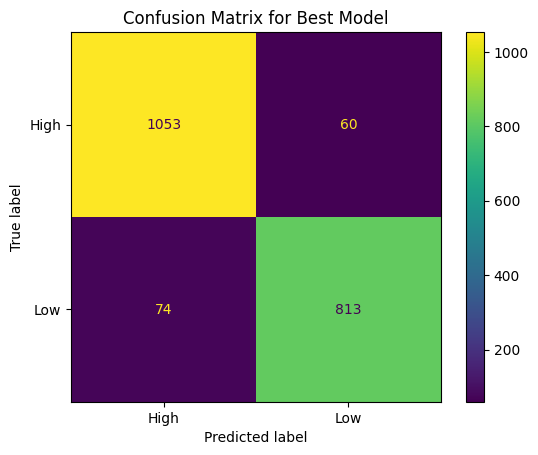

In [9]:
ConfusionMatrixDisplay.from_predictions(y_test, best_predictions)
plt.title("Confusion Matrix for Best Model")
plt.show()

## Stage 10 — Visualisation of Model Output

This simple chart compares the algorithms so we can clearly explain why the best model was chosen.

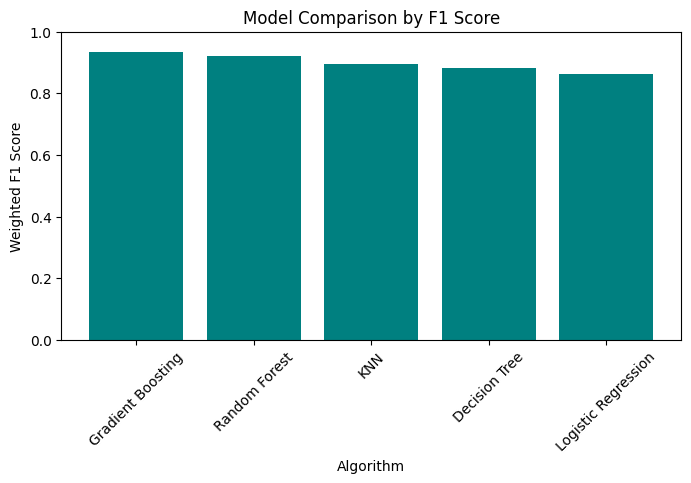

In [10]:
plt.figure(figsize=(8, 4))
plt.bar(results_df["algorithm"], results_df["f1_score"], color="teal")
plt.title("Model Comparison by F1 Score")
plt.xlabel("Algorithm")
plt.ylabel("Weighted F1 Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()

## Stage 11 — Model Optimization

The first optimization is choosing the strongest model from several options. Next, we tune the best model using a small hyperparameter grid.

In [11]:
results_df.to_csv(project_dir / "data" / "final" / "model_comparison_results.csv", index=False)
results_df

,algorithm,accuracy,f1_score
4,Gradient Boosting,0.9330,0.932943
3,Random Forest,0.9205,0.920467
1,KNN,0.8970,0.897000
2,Decision Tree,0.8830,0.883099
0,Logistic Regression,0.8625,0.862460


## Stage 12 — Model Tuning (Hyperparameter Tuning)

We tune only the model family that performed best.

In [12]:
param_grid = {
    "model__n_estimators": [80, 120],
    "model__max_depth": [None, 8, 14],
    "model__min_samples_leaf": [1, 2],
}

tuning_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(random_state=42)),
])

grid_search = GridSearchCV(
    tuning_pipeline,
    param_grid,
    scoring="f1_weighted",
    cv=3,
    n_jobs=1,
)

grid_search.fit(X_train, y_train)
tuned_model = grid_search.best_estimator_
tuned_predictions = tuned_model.predict(X_test)

print("Best parameters:", grid_search.best_params_)
print("Tuned accuracy:", accuracy_score(y_test, tuned_predictions))
print("Tuned F1:", f1_score(y_test, tuned_predictions, average="weighted"))

Best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 120}
Tuned accuracy: 0.938
Tuned F1: 0.9379781297134239


In [13]:
joblib.dump(tuned_model, models_dir / "smart_business_recommender_model.joblib")
print("Saved model:", models_dir / "smart_business_recommender_model.joblib")

Saved model: ..\models\smart_business_recommender_model.joblib


## Stage 13 — Model Deployment with Gradio

The final interface uses only the cleaned project dataset and trained model. The user does not upload a spreadsheet in this final version. Instead, the user enters business context such as region, customer group, shop type, rainfall level, temperature level, and age. The model recommends business/product categories, while the LLM uses the user's age to explain suitable business opportunities in simple language.

In [14]:
# Final deployment uses the cleaned project data only.
# No spreadsheet upload is required in this final product version.
print("Final Gradio version will use only the project dataset and trained model.")

Final Gradio version will use only the project dataset and trained model.


In [15]:
def value_from_level(column, level):
    if level == "Low":
        return float(df[column].quantile(0.25))
    if level == "Medium":
        return float(df[column].quantile(0.50))
    return float(df[column].quantile(0.75))

def high_probability(model, row):
    probabilities = model.predict_proba(row)[0]
    classes = list(model.classes_)
    if "High" in classes:
        return float(probabilities[classes.index("High")])
    return 0.0

def age_group_from_age(age):
    age = int(age)
    if age < 25:
        return "young entrepreneur/student age group"
    if age < 40:
        return "early-career adult age group"
    if age < 60:
        return "experienced adult age group"
    return "senior/experienced community member age group"

In [16]:
def local_business_explanation(best_category, top_products, region, rainfall_level, temperature_level, age):
    products_text = ", ".join(top_products[:5])
    age_group = age_group_from_age(age)
    return f'''
Recommended business opportunity: {best_category} in {region}.

Why this may fit: the model ranked this category highly for {rainfall_level.lower()} rainfall and {temperature_level.lower()} temperature. Useful starting products are: {products_text}.

Age-aware advice: for a {age_group}, begin with a manageable stock size, control costs carefully, and choose products that match your available time, energy, capital, and experience.

First small steps: visit nearby shops or markets, compare prices, ask customers what they buy often, start with a few fast-moving products, and record daily sales.

Important caution: this is a school prototype recommendation. It supports decision-making, but it does not guarantee profit.
'''.strip()

def openai_business_explanation(best_category, top_products, region, rainfall_level, temperature_level, customer_group, shop_type, age):
    fallback = local_business_explanation(best_category, top_products, region, rainfall_level, temperature_level, age)
    if not os.getenv("OPENAI_API_KEY"):
        return fallback + "\n\nLLM note: Add OPENAI_API_KEY to the .env file to get an OpenAI-generated explanation."

    try:
        from openai import OpenAI
        client = OpenAI()
        age_group = age_group_from_age(age)
        prompt = f'''
Explain this smart business recommendation in simple language for a person in Tanzania.
The person is {age} years old, which is the {age_group}.
Region: {region}
Customer group: {customer_group}
Shop type: {shop_type}
Rainfall level: {rainfall_level}
Temperature level: {temperature_level}
Recommended business category: {best_category}
Top products: {", ".join(top_products[:10])}

Give practical advice about:
1. why this business opportunity may fit the person,
2. how age/life stage can affect capital, energy, risk, and management style,
3. what first small steps they can take,
4. important caution that this is a prototype educational recommendation, not guaranteed profit.

Keep the answer short, clear, encouraging, and suitable for a school capstone presentation.
'''
        model_name = os.getenv("OPENAI_MODEL", "gpt-4o-mini")
        response = client.responses.create(
            model=model_name,
            input=prompt,
            max_output_tokens=350,
        )
        response_text = getattr(response, "output_text", "")
        if response_text:
            return response_text.strip()
        return fallback + "\n\nLLM note: OpenAI returned an empty response, so the local explanation is shown."
    except Exception as error:
        error_text = str(error).lower()
        if "insufficient_quota" in error_text or "429" in error_text:
            return fallback + "\n\nLLM note: OpenAI could not generate text because the API quota/billing limit was reached. The local age-aware explanation is shown instead."
        if "model" in error_text:
            return fallback + "\n\nLLM note: OpenAI could not generate text because the model setting may be unavailable. Check OPENAI_MODEL in .env."
        return fallback + "\n\nLLM note: OpenAI could not generate text now, so the local age-aware explanation is shown instead."

In [17]:
def recommend_business(region, month, rainfall_level, temperature_level, customer_group, shop_type, age):
    training_data = df.copy()
    current_model = tuned_model if "tuned_model" in globals() else best_model

    rainfall_value = value_from_level("rainfall_mm", rainfall_level)
    temperature_value = value_from_level("temperature_c", temperature_level)

    category_rows = []
    for category in sorted(training_data["product_category"].unique()):
        category_data = training_data[training_data["product_category"] == category]
        common_product = category_data["product_name"].mode().iloc[0]
        typical_price = category_data["unit_price_tzs"].median()
        test_row = pd.DataFrame([{
            "month": month,
            "region": region,
            "rainfall_mm": rainfall_value,
            "temperature_c": temperature_value,
            "customer_group": customer_group,
            "shop_type": shop_type,
            "product_category": category,
            "product_name": common_product,
            "unit_price_tzs": typical_price,
        }])
        category_rows.append({
            "product_category": category,
            "example_product": common_product,
            "high_demand_probability": high_probability(current_model, test_row),
        })

    category_result = pd.DataFrame(category_rows).sort_values("high_demand_probability", ascending=False)
    best_category = category_result.iloc[0]["product_category"]

    product_result = (
        training_data[training_data["product_category"] == best_category]
        .groupby("product_name", as_index=False)
        .agg(avg_units_sold=("units_sold", "mean"), median_price_tzs=("unit_price_tzs", "median"))
        .sort_values("avg_units_sold", ascending=False)
        .head(10)
    )

    fig, ax = plt.subplots(figsize=(5, 5))
    pie_data = category_result.head(5)
    ax.pie(
        pie_data["high_demand_probability"],
        labels=pie_data["product_category"],
        autopct="%1.1f%%",
        startangle=90,
    )
    ax.set_title("Top Category Recommendation Scores")

    explanation = openai_business_explanation(
        best_category,
        product_result["product_name"].tolist(),
        region,
        rainfall_level,
        temperature_level,
        customer_group,
        shop_type,
        age,
    )

    return category_result, product_result, fig, explanation

In [18]:
import gradio as gr

region_choices = sorted(df["region"].unique().tolist())
customer_choices = sorted(df["customer_group"].unique().tolist())
shop_choices = sorted(df["shop_type"].unique().tolist())

with gr.Blocks(title="Smart Business Recommender for Tanzania") as demo:
    gr.HTML(
        '''
        <style>
        body { background: #fff8f0; }
        .gradio-container { background-color: #fff8f0; }
        .gr-button { background-color: orange !important; color: white !important; border-color: darkorange !important; }
        .gr-button:hover { background-color: darkorange !important; }
        .gr-textbox, .gr-dropdown, .gr-dataframe, .gradio-plot { border-radius: 10px; }
        .gr-markdown { color: #302b27; }
        </style>
        '''
    )

    gr.Markdown("# Smart Business Recommender for Tanzania")
    gr.Markdown(
        "Choose a Tanzanian business context. The system uses our cleaned project dataset and trained ML model, "
        "then the LLM explains the recommendation using the user's age."
    )

    with gr.Row():
        region_input = gr.Dropdown(region_choices, label="Tanzania Region", value=region_choices[0])
        age_input = gr.Slider(16, 75, value=25, step=1, label="Your Age")

    with gr.Row():
        month_input = gr.Dropdown([1, 4, 7, 10], label="Month", value=1)
        rainfall_input = gr.Dropdown(["Low", "Medium", "High"], label="Rainfall Level", value="Medium")
        temperature_input = gr.Dropdown(["Low", "Medium", "High"], label="Temperature Level", value="Medium")

    with gr.Row():
        customer_input = gr.Dropdown(customer_choices, label="Customer Group", value=customer_choices[0])
        shop_input = gr.Dropdown(shop_choices, label="Shop Type", value=shop_choices[0])

    recommend_button = gr.Button("Get Recommendation")

    category_output = gr.Dataframe(label="Recommended Product Categories")
    product_output = gr.Dataframe(label="Top 10 Products in Best Category")
    pie_output = gr.Plot(label="Recommendation Pie Chart")
    explanation_output = gr.Textbox(label="LLM Business Advice Based on Age", lines=10)

    recommend_button.click(
        recommend_business,
        inputs=[region_input, month_input, rainfall_input, temperature_input, customer_input, shop_input, age_input],
        outputs=[category_output, product_output, pie_output, explanation_output],
    )

demo.launch()

d:\From Desktop\Desktop\SSE\CAPSTONE-PROJECT\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


## Stage 14 — Monitoring and Improvement Plan

This notebook ends at deployment, but the next step is monitoring. The team should collect user feedback, compare recommendations against actual sales, and retrain weekly or monthly when enough new data is available.